# Functions to parse and clean data

### Imports

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Parse data

In [2]:
# PARSING 
def parse_custom_csv(path):
    with open(path, "r") as f:
        lines = f.readlines()

    sections = {"META": [], "EVENTS": [], "METER": []}
    current = None

    for line in lines:
        line = line.strip()

        if line.startswith("#"):
            current = line.replace("#", "").strip() #define current section as the header
            continue

        if current and line:  # <-- FIX: skip empty lines
            sections[current].append(line)

    # META
    meta = {}
    for row in sections["META"]:
        k, v = row.split(",", 1)
        meta[k] = v

   # EVENTS
    header = sections["EVENTS"][0].split(",")
    data = [r.split(",") for r in sections["EVENTS"][1:]]
    events = pd.DataFrame(data, columns=header)
    

    # METER
    clean_rows = []
    header = sections["METER"][0].split(",")
    for line in sections["METER"][1:]:
        parts = line.split(",")
        # Only keep valid rows with exactly 3 columns
        if len(parts) != 3:
            continue
        clean_rows.append(parts)
    meter = pd.DataFrame(clean_rows, columns=["timestamp", "v_shunt", "phase"])
    

    return meta, events, meter

## Clean data

In [3]:
# CLEANING
def clean_data(meta, meter, run_id):

    meter["timestamp"] = pd.to_datetime(meter["timestamp"])
    meter["v_shunt"] = meter["v_shunt"].astype(float)

    # Add run id
    meter["run"] = run_id

    # Add payload size
    meter["payload_size"] = 0
    # TX rows
    tx_mask = meter["phase"].astype(str).str.startswith("tx_")
    meter.loc[tx_mask, "payload_size"] = (
        meter.loc[tx_mask, "phase"]
        .str.replace("tx_", "")
        .astype(int)
    )
    return meta, meter

## Align timings and label phases
So that time is standard over all runs

In [4]:
def align_time(meter):
    # Find first non-baseline timestamp
    non_baseline = meter[meter["phase"] != "baseline"]

    if len(non_baseline) == 0:
        raise ValueError("No non-baseline data found")

    t0 = non_baseline["timestamp"].iloc[0]

    # Create relative time
    meter["t_s"] = (meter["timestamp"] - t0).dt.total_seconds()

    return meter

## Test the functions

In [5]:
file1 = Path("/Users/jude/Documents/GitHub/BTR/experiments/WiFi/experiment 2 (byte-for-byte)/data/esp32/byte_by_byte/new best/esp32_byte_by_byte_run01.csv")
meta1, events1, meter1 = parse_custom_csv(file1)
meta1, meter1 = clean_data(meta1, meter1, run_id=1)
meter1 = align_time(meter1)
print(events1.head())
print(meter1.head())


Empty DataFrame
Columns: [run, payload_size, declared_size, bytes_received, tx_start, rx_end, complete, verified, skip_reason]
Index: []
                timestamp   v_shunt     phase  run  payload_size    t_s
0 2026-03-29 19:33:03.190  0.106703  baseline    1             0 -4.989
1 2026-03-29 19:33:03.193  0.106610  baseline    1             0 -4.986
2 2026-03-29 19:33:03.197  0.106610  baseline    1             0 -4.982
3 2026-03-29 19:33:03.200  0.106610  baseline    1             0 -4.979
4 2026-03-29 19:33:03.203  0.106610  baseline    1             0 -4.976


Run on all files

In [6]:
all_meter = []
all_events = []

data_dir = Path("/Users/jude/Documents/GitHub/BTR/experiments/WiFi/experiment 2 (byte-for-byte)/data/esp32/byte_by_byte/new best/")

for i, file in enumerate(sorted(data_dir.glob("*.csv"))):
    meta, events, meter = parse_custom_csv(file)
    meta, meter = clean_data(meta, meter, run_id=i+1)
    meter = align_time(meter)

    all_meter.append(meter)
    all_events.append(events)

meter_df = pd.concat(all_meter, ignore_index=True)
events_df = pd.concat(all_events, ignore_index=True)

In [7]:
print(meter_df)

                      timestamp   v_shunt     phase  run  payload_size  \
0       2026-03-29 19:33:03.190  0.106703  baseline    1             0   
1       2026-03-29 19:33:03.193  0.106610  baseline    1             0   
2       2026-03-29 19:33:03.197  0.106610  baseline    1             0   
3       2026-03-29 19:33:03.200  0.106610  baseline    1             0   
4       2026-03-29 19:33:03.203  0.106610  baseline    1             0   
...                         ...       ...       ...  ...           ...   
3242609 2026-03-29 20:26:36.784  0.107155      idle   30             0   
3242610 2026-03-29 20:26:36.787  0.107155      idle   30             0   
3242611 2026-03-29 20:26:36.791  0.107155      idle   30             0   
3242612 2026-03-29 20:26:36.793  0.107155      idle   30             0   
3242613 2026-03-29 20:26:36.795  0.107155      idle   30             0   

             t_s  
0         -4.989  
1         -4.986  
2         -4.982  
3         -4.979  
4         -4.976

# Stats and plots 

Ok so i want

For **each seperate run**: mean power during transmissons, std (within run variation) and count, time spent in transmission state 
- tx 1 : avg v_shunt, std of v_shunt, count of measurements, Time 
- etc.

For **all runs**: Mean power of all ?byte transmission, std (between run variation) (count is 30), avg time spent in tx of payload, std and count ?


In [81]:
voltage_df = meter_df.copy()

### Power
Power: 
P = V_supply * I

Current: 
I = V_shunt/R

In [8]:
R = 1.131667        # ohms
V_supply = 5.013517 # volts

meter_df["current_A"] = meter_df["v_shunt"] / R
meter_df["power_W"] = V_supply * meter_df["current_A"]

print(meter_df[["current_A","power_W"]])

         current_A   power_W
0         0.094288  0.472716
1         0.094206  0.472304
2         0.094206  0.472304
3         0.094206  0.472304
4         0.094206  0.472304
...            ...       ...
3242609   0.094688  0.474719
3242610   0.094688  0.474719
3242611   0.094688  0.474719
3242612   0.094688  0.474719
3242613   0.094688  0.474719

[3242614 rows x 2 columns]


In [68]:
# Uncertainties
#power_uncertainty = delta_Vsupply / V_supply + delta_Vshunt / v_shunt + delta_R / R

R_unc = 0.05 * R  # 5%
V_supply_unc = 0.01 * V_supply  # example, depends on meter
V_shunt_unc = 0.001  # approximation bcs its percent of value + 2tomes last digit (9 0's after decimal in our case)

meter_df["power_unc"] = meter_df["power_W"] * np.sqrt(
    (V_supply_unc / V_supply)**2 +
    (V_shunt_unc / meter_df["v_shunt"])**2 +
    (R_unc / R)**2
)

In [69]:
print(meter_df.columns)

Index(['timestamp', 'v_shunt', 'phase', 'run', 'payload_size', 't_s',
       'current_A', 'power_W', 'power_unc'],
      dtype='object')


### Per run

In [70]:
nonbaseline_df = meter_df[meter_df["phase"] != "baseline"]

'''per_run_stats = (
    nonbaseline_df
    .groupby(["run", "payload_size"])
    .agg(
        mean_v_shunt=("v_shunt", "mean"),
        std_v_shunt=("v_shunt", "std"),

        mean_power=("power_W", "mean"),
        std_power=("power_W", "std"),

        count=("v_shunt", "count"),
        duration_s=("t_s", lambda x: x.max() - x.min())
    )
    .reset_index()
)'''

per_run_stats = (
    nonbaseline_df
    .groupby(["run", "payload_size"])
    .agg(
        mean_v_shunt=("v_shunt", "mean"),
        std_v_shunt=("v_shunt", "std"),
        
        mean_power=("power_W", "mean"),
        std_power=("power_W", "std"),
        count=("power_W", "count"),
        duration_s=("t_s", lambda x: x.max() - x.min()),

        # measurement uncertainty propagation
        mean_power_unc=("power_unc", lambda x: np.sqrt((x**2).sum()) / len(x))
    ) 
    .assign(
        se_power=lambda df: df["std_power"] / np.sqrt(df["count"])
    )
    .reset_index()
)

baseline_stats = (
    meter_df[meter_df["phase"] == "baseline"]
    .groupby("run")
    .agg(
        baseline_mean_v_shunt=("v_shunt", "mean"),
        baseline_std_v_shunt=("v_shunt", "std"),

        baseline_mean_power=("power_W", "mean"),
        baseline_std_power=("power_W", "std"),
        baseline_count=("power_W", "count"),
        mean_baseline_power_unc=("power_unc", lambda x: np.sqrt((x**2).sum()) / len(x))
    )
    .reset_index()
)

In [71]:
print(per_run_stats.head())
print(per_run_stats.tail())

   run  payload_size  mean_v_shunt  std_v_shunt  mean_power  std_power  count  \
0    1             0      0.107026     0.002671    0.474145   0.011833   5166   
1    1             2      0.106803     0.000003    0.473161   0.000013     28   
2    1             4      0.106820     0.000095    0.473235   0.000420     63   
3    1             8      0.105782     0.004268    0.468638   0.018906    110   
4    1            16      0.106887     0.000076    0.473530   0.000338     69   

   duration_s  mean_power_unc  se_power  
0     388.950        0.000342  0.000165  
1       0.109        0.004636  0.000003  
2       0.254        0.003091  0.000053  
3       0.493        0.002319  0.001803  
4       0.241        0.002955  0.000041  
     run  payload_size  mean_v_shunt  std_v_shunt  mean_power  std_power  \
608   30         32768      0.112230     0.003301    0.497201   0.014626   
609   30         65536      0.108137     0.006807    0.479069   0.030158   
610   30        131072      0.111

In [72]:
print(baseline_stats.head())

   run  baseline_mean_v_shunt  baseline_std_v_shunt  baseline_mean_power  \
0    1               0.107386              0.001831             0.475741   
1    2               0.109555              0.004555             0.485352   
2    3               0.107346              0.001022             0.475567   
3    4               0.110255              0.000673             0.488451   
4    5               0.108486              0.002862             0.480616   

   baseline_std_power  baseline_count  mean_baseline_power_unc  
0            0.008111            1288                 0.000687  
1            0.020180            1196                 0.000728  
2            0.004529            1585                 0.000619  
3            0.002981            1528                 0.000647  
4            0.012681            1569                 0.000629  


### Across runs

In [73]:
'''across_runs_stats = (
    per_run_stats
    .groupby("payload_size")
    .agg(
        mean_v_shunt=("mean_v_shunt", "mean"),
        std_v_shunt=("mean_v_shunt", "std"),
        count_runs=("mean_v_shunt", "count"),

        mean_power=("mean_power", "mean"),
        std_power=("mean_power", "std"),

        mean_duration=("duration_s", "mean"),
        std_duration=("duration_s", "std"),
    )
    .reset_index()
)'''

across_runs_stats = (
    per_run_stats
    .groupby("payload_size")
    .agg(
        #mean_v_shunt=("mean_v_shunt", "mean"),
        #std_v_shunt=("mean_v_shunt", "std"),
        
        mean_power=("mean_power", "mean"),
        std_runs=("mean_power", "std"),
        count_runs=("mean_power", "count"),

        mean_duration=("duration_s", "mean"),
        std_duration=("duration_s", "std"),

        # propagate measurement uncertainty across runs
        mean_measurement_unc=("mean_power_unc", lambda x: np.sqrt((x**2).sum()) / len(x))
    )
    .assign(
        # standard error (repeatability)
        se_runs=lambda df: df["std_runs"] / np.sqrt(df["count_runs"]), #std/sqrt(n)

        se_duration=lambda df: df["std_duration"] / np.sqrt(df["count_runs"]),

        # total uncertainty
        total_unc=lambda df: np.sqrt(
            df["se_runs"]**2 +
            df["mean_measurement_unc"]**2
        ), #sqrt(se^2 + meas_unc^2)

        # 95% confidence interval
        ci95=lambda df: 1.96 * df["total_unc"],
        ci95_duration=lambda df: 1.96 * df["se_duration"]
    )
    .reset_index()
)

across_runs_stats = across_runs_stats[across_runs_stats["payload_size"] != 1] #exclude 1 byte cause its not in every run 
print(across_runs_stats)

    payload_size  mean_power  std_runs  count_runs  mean_duration  \
0              0    0.474351  0.004805          30     377.552567   
2              2    0.470587  0.012350          30       0.184033   
3              4    0.473824  0.010337          30       0.282333   
4              8    0.471136  0.009044          30       0.343267   
5             16    0.470517  0.008961          30       0.377233   
6             32    0.474153  0.008226          30       0.294033   
7             64    0.468840  0.013992          30       0.423133   
8            128    0.472652  0.004787          30       0.307733   
9            256    0.466857  0.009809          30       0.685933   
10           512    0.469269  0.011513          30       0.634067   
11          1024    0.473099  0.012120          30       1.118200   
12          2048    0.481504  0.009474          30       1.731000   
13          4096    0.485082  0.013353          30       2.568100   
14          8192    0.487042  0.01

In [77]:
print(across_runs_stats["std_duration"])

0     52.391820
2      0.212940
3      0.183548
4      0.222778
5      0.303806
6      0.091199
7      0.329351
8      0.108472
9      0.805872
10     0.362488
11     0.739231
12     1.206318
13     0.648882
14     1.145541
15     1.320686
16     1.264091
17     2.080024
18     5.027215
19    22.875407
20    30.878743
Name: std_duration, dtype: float64


1              1    0.468605  0.022233          13              0.006066


HUHHHH

ok so i deleted payload 1 cause it exists only sometimes

### Graph time?

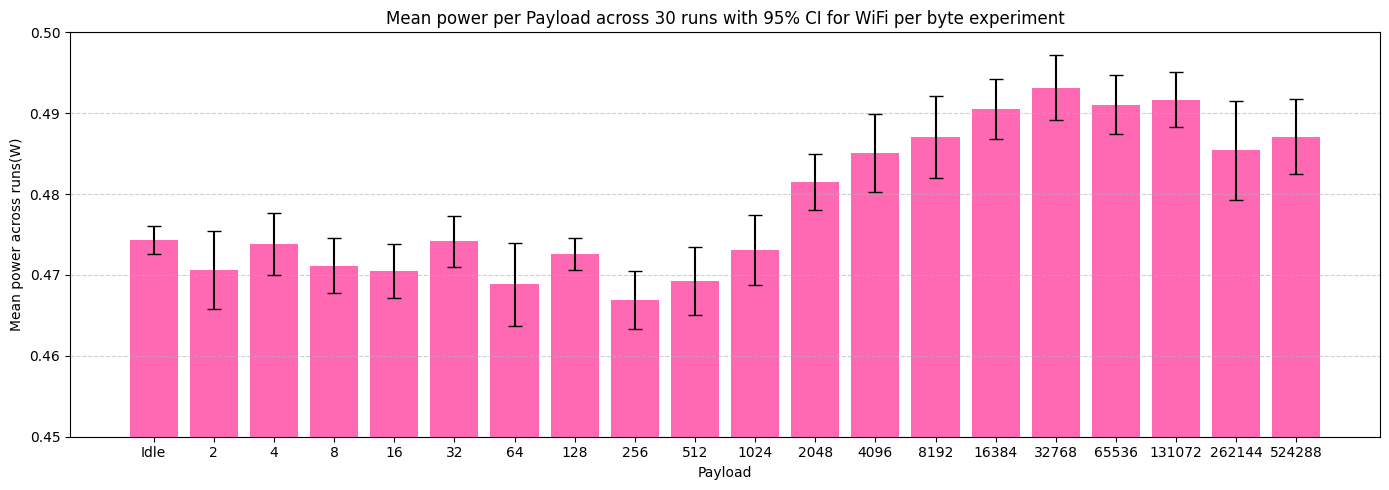

In [74]:
df = across_runs_stats.copy()

# Replace 0 with "Idle"
df["payload_label"] = df["payload_size"].astype(str)
df.loc[df["payload_size"] == 0, "payload_label"] = "Idle"

plt.figure(figsize=(14,5))

plt.bar(
    df["payload_label"],
    df["mean_power"],
    yerr=df["ci95"],
    capsize=5,
    color='hotpink'
)
#cut off y axis at 0.5
plt.ylim(0.45, 0.5)
plt.xlabel("Payload")
plt.ylabel("Mean power across runs(W)")
plt.title("Mean power per Payload across 30 runs with 95% CI for WiFi per byte experiment")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

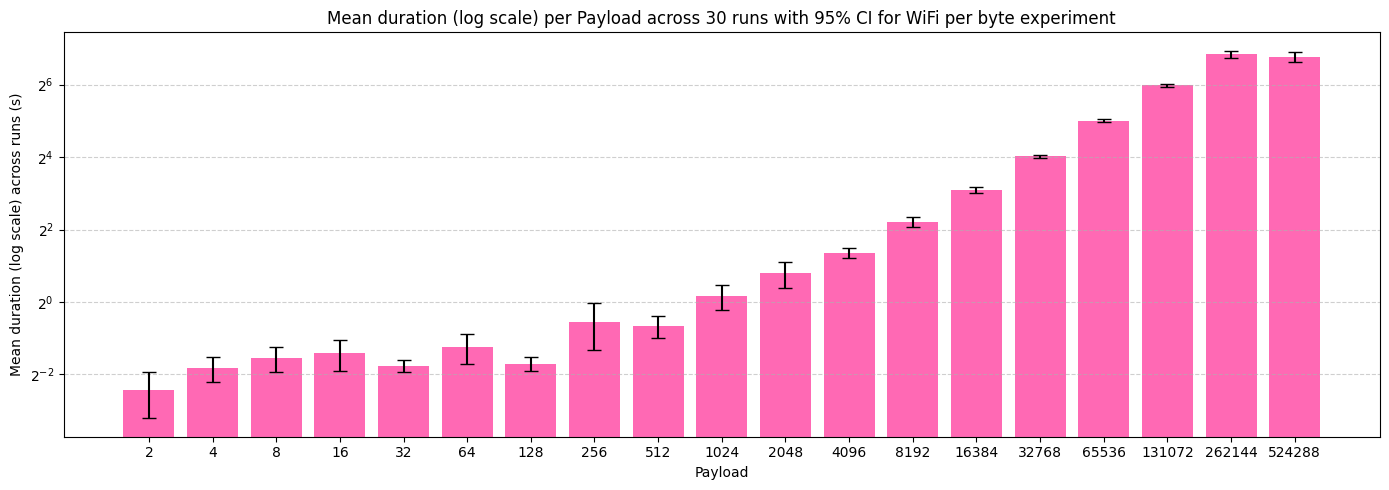

In [123]:
#exclude idle cause way l9nger and irrelevant duration
df = df[df["payload_size"] != 0]

fig, ax = plt.subplots(figsize=(14,5))

ax.bar(
    df["payload_label"],
    df["mean_duration"],
    yerr=df["ci95_duration"],
    capsize=5,
    color='hotpink'
)

#needs to be log scale to show the difference between 1 byte and 1000 bytes, otherwise the 1 byte bar is invisible
ax.set_yscale('log', base=2)

ax.set_xlabel("Payload")
ax.set_ylabel("Mean duration (log scale) across runs (s)")
ax.set_title("Mean duration (log scale) per Payload across 30 runs with 95% CI for WiFi per byte experiment")

ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Energy

in joules per run per payload

In [105]:
print(meter_df)

                      timestamp   v_shunt     phase  run  payload_size  \
0       2026-03-29 19:33:03.190  0.106703  baseline    1             0   
1       2026-03-29 19:33:03.193  0.106610  baseline    1             0   
2       2026-03-29 19:33:03.197  0.106610  baseline    1             0   
3       2026-03-29 19:33:03.200  0.106610  baseline    1             0   
4       2026-03-29 19:33:03.203  0.106610  baseline    1             0   
...                         ...       ...       ...  ...           ...   
3242609 2026-03-29 20:26:36.784  0.107155      idle   30             0   
3242610 2026-03-29 20:26:36.787  0.107155      idle   30             0   
3242611 2026-03-29 20:26:36.791  0.107155      idle   30             0   
3242612 2026-03-29 20:26:36.793  0.107155      idle   30             0   
3242613 2026-03-29 20:26:36.795  0.107155      idle   30             0   

             t_s  current_A   power_W  power_unc  
0         -4.989   0.094288  0.472716   0.024508  
1        

In [ ]:
def energy_with_unc(df):
    df = df.sort_values("t_s")   #make sure data is ordered by time
    # Time differences between samples (Δt)
    dt = df["t_s"].diff().fillna(0) #dt is time difference btw samples within a run and payload size group 

    # Energy: sum of P * Δt
    energy = (df["power_W"] * dt).sum()

    # Uncertainty propagation: sqrt(sum((Δt * u_P)^2))
    energy_unc = np.sqrt(((dt * df["power_unc"])**2).sum()) #we assume time uncertainty (from measurements) is negligeable

    return pd.Series({
        "energy_J": energy,
        "energy_unc": energy_unc
    })


energy_per_run = (
    meter_df[meter_df["payload_size"] != 0]   #remove idle and baseline
    .groupby(["run", "payload_size"])       
    .apply(energy_with_unc)                   #compute energy + uncertainty
    .reset_index()                            #clean dataframe
)

/var/folders/y0/ntq2pbh53yb4nxf1rt5x3bxw0000gq/T/ipykernel_34870/2577615015.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(energy_with_unc)                   #compute energy + uncertainty


In [110]:
print(energy_per_run)

     run  payload_size   energy_J  energy_unc
0      1             2   0.051575    0.000556
1      1             4   0.120211    0.000852
2      1             8   0.230665    0.001308
3      1            16   0.114121    0.000789
4      1            32   0.105483    0.000797
..   ...           ...        ...         ...
578   30         32768   7.981238    0.007190
579   30         65536  17.352483    0.011729
580   30        131072  31.287345    0.014570
581   30        262144  52.139770    0.015888
582   30        524288  14.690684    0.008947

[583 rows x 4 columns]


In [115]:
energy_stats = (
    energy_per_run[energy_per_run["payload_size"] != 1]
    .groupby("payload_size")
    .agg(
        mean_energy=("energy_J", "mean"),
        std_energy=("energy_J", "std"),
        count_runs=("energy_J", "count"),

        mean_energy_unc=("energy_unc", lambda x: np.sqrt((x**2).sum()) / len(x))
    )
    .assign(
        se_runs=lambda df: df["std_energy"] / np.sqrt(df["count_runs"]),
        total_unc=lambda df: np.sqrt(df["se_runs"]**2 + df["mean_energy_unc"]**2),
        ci95=lambda df: 1.96 * df["total_unc"]
    )
    .reset_index()
)
print(energy_stats)

    payload_size  mean_energy  std_energy  count_runs  mean_energy_unc  \
0              2     0.084478    0.093874          30         0.000122   
1              4     0.132435    0.080347          30         0.000160   
2              8     0.159847    0.098267          30         0.000181   
3             16     0.175449    0.137450          30         0.000191   
4             32     0.139048    0.041760          30         0.000165   
5             64     0.194102    0.142041          30         0.000195   
6            128     0.144960    0.048780          30         0.000170   
7            256     0.319066    0.377186          30         0.000249   
8            512     0.295850    0.166248          30         0.000253   
9           1024     0.524255    0.337516          30         0.000328   
10          2048     0.831102    0.581386          30         0.000412   
11          4096     1.242027    0.296106          30         0.000612   
12          8192     2.248894    0.485

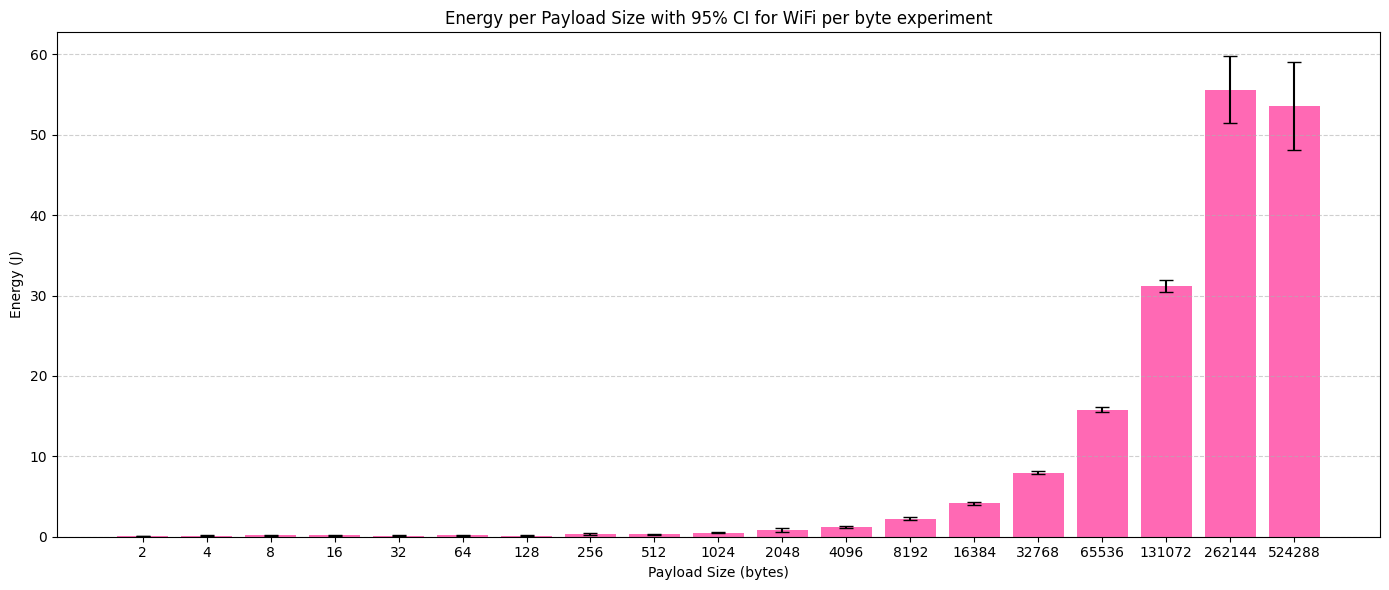

In [120]:
plt.figure(figsize=(14, 6))
plt.bar(
    energy_stats["payload_size"].astype(str),
    energy_stats["mean_energy"],
    yerr=energy_stats["ci95"],
    capsize=5,
    color='hotpink'
)
plt.xlabel("Payload Size (bytes)")
plt.ylabel("Energy (J)")
plt.title("Energy per Payload Size with 95% CI for WiFi per byte experiment")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
print(energy_stats[["payload_size", "mean_energy"]])

    payload_size  mean_energy
0              2     0.084478
1              4     0.132435
2              8     0.159847
3             16     0.175449
4             32     0.139048
5             64     0.194102
6            128     0.144960
7            256     0.319066
8            512     0.295850
9           1024     0.524255
10          2048     0.831102
11          4096     1.242027
12          8192     2.248894
13         16384     4.154958
14         32768     7.986169
15         65536    15.791843
16        131072    31.185800
17        262144    55.640386
18        524288    53.584083


: 

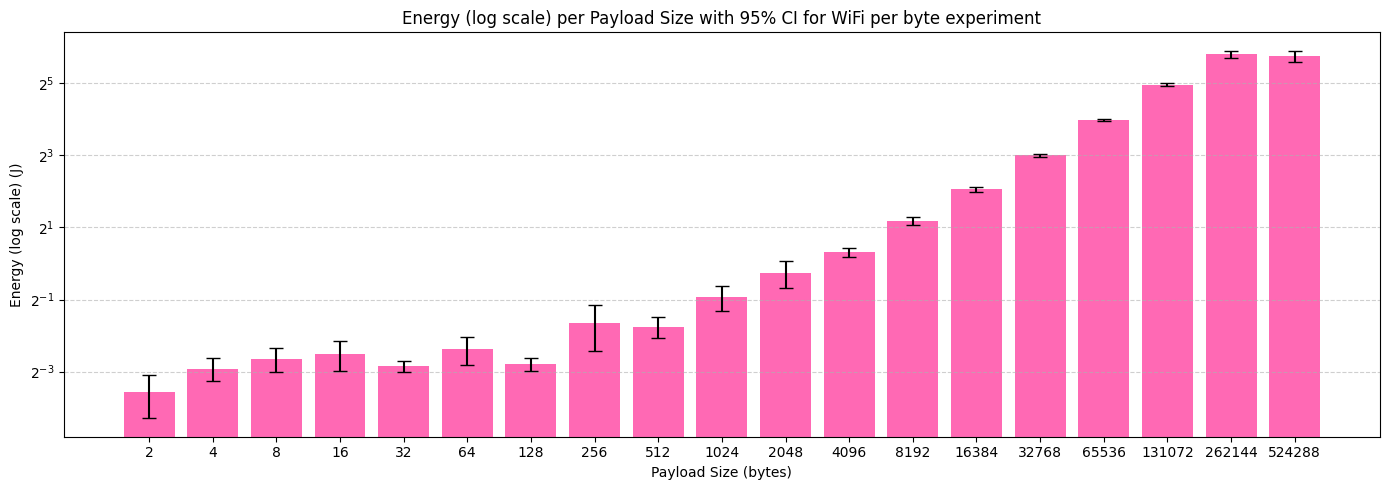

In [124]:
fig, ax = plt.subplots(figsize=(14,5))
ax.bar(
    energy_stats["payload_size"].astype(str),
    energy_stats["mean_energy"],
    yerr=energy_stats["ci95"],
    capsize=5,
    color='hotpink'
)
#gotta log scale it
ax.set_yscale('log', base=2)

ax.set_xlabel("Payload Size (bytes)")
ax.set_ylabel("Energy (log scale) (J)")
ax.set_title("Energy (log scale) per Payload Size with 95% CI for WiFi per byte experiment")
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Old stats without power

## Stats about voltage
nothing about power yet cause i dont know shunt resistance

In [95]:
voltage_df = voltage_df[voltage_df["payload_size"] != 1]
summary_V_shunt = (
    voltage_df
    .groupby("payload_size")["v_shunt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary_V_shunt["sem"] = summary_V_shunt["std"] / np.sqrt(summary_V_shunt["count"])  # standard error
summary_V_shunt["ci95"] = 1.96 * summary_V_shunt["sem"]  # 95% confidence interval

print(summary_V_shunt)

    payload_size      mean       std   count       sem      ci95
0              0  0.107317  0.005914  224279  0.000012  0.000024
1              2  0.103618  0.005649    1689  0.000137  0.000269
2              4  0.105753  0.004399    2458  0.000089  0.000174
3              8  0.105044  0.004846    3001  0.000088  0.000173
4             16  0.104987  0.004478    3161  0.000080  0.000156
5             32  0.106801  0.002631    2575  0.000052  0.000102
6             64  0.103804  0.005600    3534  0.000094  0.000185
7            128  0.106384  0.002480    2614  0.000049  0.000095
8            256  0.104975  0.004367    5947  0.000057  0.000111
9            512  0.105172  0.004657    5285  0.000064  0.000126
10          1024  0.105874  0.005351    9180  0.000056  0.000109
11          2048  0.108307  0.006216   14603  0.000051  0.000101
12          4096  0.109104  0.005184   21314  0.000036  0.000070
13          8192  0.109567  0.006195   38642  0.000032  0.000062
14         16384  0.11051

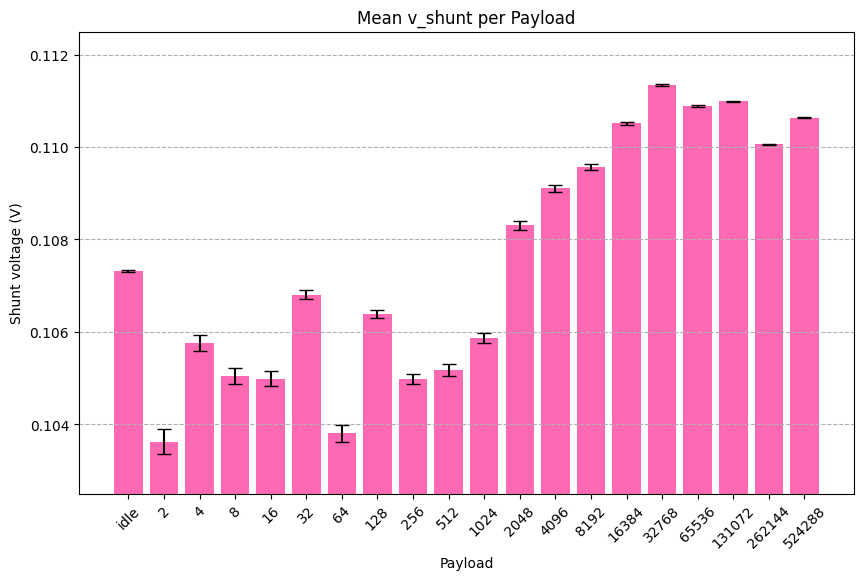

In [100]:
summary_V_shunt["payload_label"] = summary_V_shunt["payload_size"].astype(str)
summary_V_shunt.loc[summary_V_shunt["payload_size"] == 0, "payload_label"] = "idle"

plt.figure(figsize=(10, 6))
plt.bar(
    summary_V_shunt["payload_label"],
    summary_V_shunt["mean"],
    yerr=summary_V_shunt["ci95"],
    capsize=5,
    color='hotpink',
)

#cut off y axis at 0.1
plt.ylim(0.1025, 0.1125)
plt.xlabel("Payload")
plt.ylabel("Shunt voltage (V)")
plt.title("Mean v_shunt per Payload")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

same thing but different, i kinda hate this

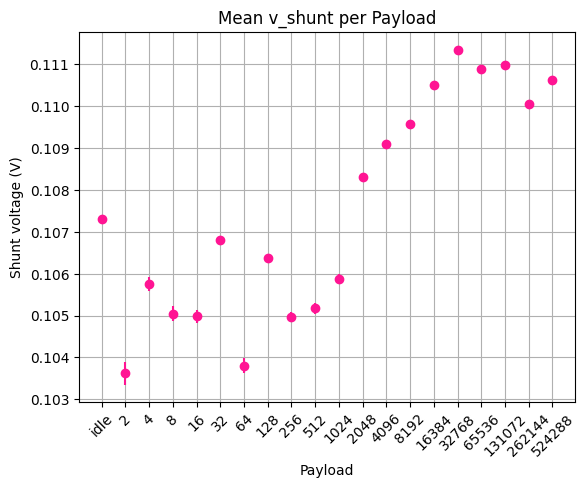

In [101]:
plt.errorbar(
    summary_V_shunt["payload_label"],
    summary_V_shunt["mean"],
    yerr=summary_V_shunt["ci95"],
    fmt='o',
    color= 'deeppink'
)

plt.xlabel("Payload")
plt.ylabel("Shunt voltage (V)")
plt.title("Mean v_shunt per Payload")
plt.xticks(rotation=45)
plt.grid()
plt.show()

wanna see outliers and stuff

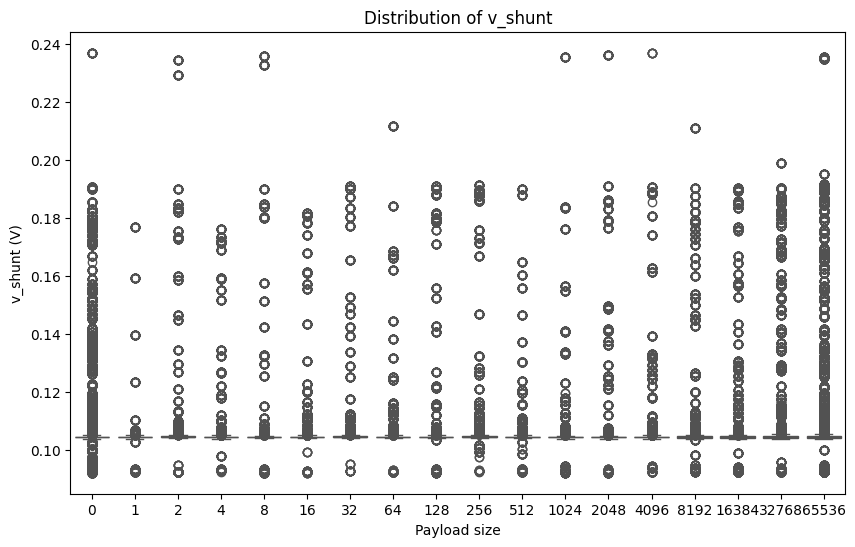

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=meter_df,
    x="payload_size",
    y="v_shunt",
    color='deeppink' #why is the color not changing?
)

plt.xlabel("Payload size")
plt.ylabel("v_shunt (V)")
plt.title("Distribution of v_shunt")
plt.show()

## Stats about time

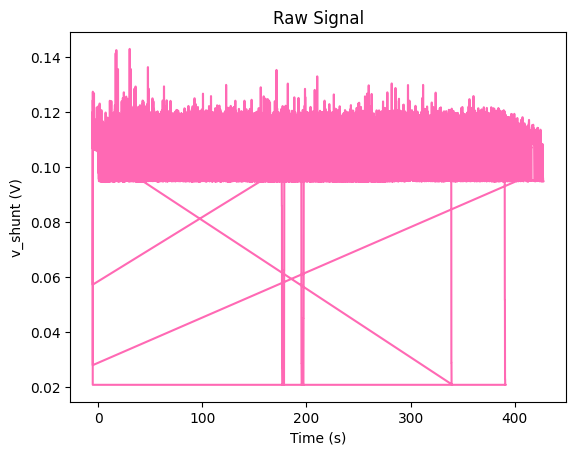

In [111]:
plt.plot(voltage_df["t_s"], voltage_df["v_shunt"], color='hotpink')
plt.xlabel("Time (s)")
plt.ylabel("v_shunt (V)")
plt.title("Raw Signal")
plt.show()

In [ ]:
events_df["duration_s"] = (
    events_df["t_end_s"] - events_df["t_start_s"]
)

tx_summary = (
    events_df
    .groupby("payload_size")["duration_s"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
tx_summary["sem"] = tx_summary["std"] / np.sqrt(tx_summary["count"])  # standard error
tx_summary["ci95"] = 1.96 * tx_summary["sem"]  #95% confidence interval
print(tx_summary)

   payload_size       mean       std  count       sem      ci95
0             1   0.599062  0.067459     16  0.016865  0.033055
1          1024   1.811875  0.047165     16  0.011791  0.023111
2           128   1.716625  0.049628     16  0.012407  0.024318
3            16   1.687625  0.092863     16  0.023216  0.045503
4         16384   3.777188  0.130683     16  0.032671  0.064035
5             2   1.726562  0.173704     16  0.043426  0.085115
6          2048   1.974875  0.085262     16  0.021315  0.041778
7           256   1.714688  0.050624     16  0.012656  0.024806
8            32   1.695562  0.045910     16  0.011478  0.022496
9         32768   5.808125  0.101231     16  0.025308  0.049603
10            4   1.703875  0.163992     16  0.040998  0.080356
11         4096   2.194125  0.083696     16  0.020924  0.041011
12          512   1.796875  0.062177     16  0.015544  0.030467
13           64   1.758750  0.057245     16  0.014311  0.028050
14        65536  10.016875  0.230474    

In [ ]:
tx_summary["payload_size"] = tx_summary["payload_size"].astype(str)
#please order omg
plt.figure()
plt.bar(
    tx_summary["payload_size"].astype(str),
    tx_summary["mean"],
    yerr=tx_summary["ci95"],
    color='hotpink'
)
plt.loc = sorted(events_df["payload_size"].unique())
plt.xlabel("Payload size")
plt.ylabel("TX duration (s)")
plt.title("Transmission Time vs Payload Size")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

NameError: name 'tx_summary' is not defined